In [104]:
# Import dependencies
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px

import matplotlib.pyplot as plt
import squarify
import matplotlib.cm as cm
# from collections import Counter
# import nltk
# from nltk.corpus import stopwords
# import string


In [105]:
# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)  # Display only the first 10 rows in output

In [106]:
# Reading all xlsx files
All_US_Open_Tasks_df = pd.read_excel('AllUSOpenTasksReport.xlsx')
US_Lead_Status_by_Owner_df = pd.read_excel('LeadStatusGroupedbyOwnerReport.xlsx')
US_LeadStatus_by_LeadSource_df = pd.read_excel('USLeadStatusGroupedbyLeadSourceReport.xlsx')


In [107]:
# Displaying column names of all dataframes
print(All_US_Open_Tasks_df.columns)
print(US_Lead_Status_by_Owner_df.columns)
print(US_LeadStatus_by_LeadSource_df.columns)

Index(['Company / Account', 'Account Type', 'Priority', 'Subject', 'Contact',
       'Lead', 'Account/Lead Rating', 'Created Date', 'Task/Event Record Type',
       'Task', 'Opportunity Lead Source', 'Contact/Lead Source', 'Created By',
       'Assigned'],
      dtype='object')
Index(['Full Name', 'Account Name', 'Lead Record Type', 'Converted Lead',
       'Created By: Full Name', 'Created Date', 'Lead Source',
       'Lead Owner: Full Name', 'Lead Status'],
      dtype='object')
Index(['Full Name', 'Account Name', 'Lead Record Type', 'Converted Lead',
       'Created By: Full Name', 'Created Date', 'Lead Status', 'Lead Currency',
       'Lead Owner: Full Name', 'Lead Source'],
      dtype='object')


### Analysis of Salesforce Report `All US Open Tasks`
#### This report shows Open Leads, Assigned to a Person, with or w/o a Lead Rating, and has at least 1 Task
#### Filters: `Status=Open or No Selection`, `does not contain: Over 1 week`

C:\Users\ykilinc\AppData\Local\Temp\ipykernel_7056\2231066887.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  All_US_Open_Tasks_df['Account Type'].fillna('Blanks', inplace=True)


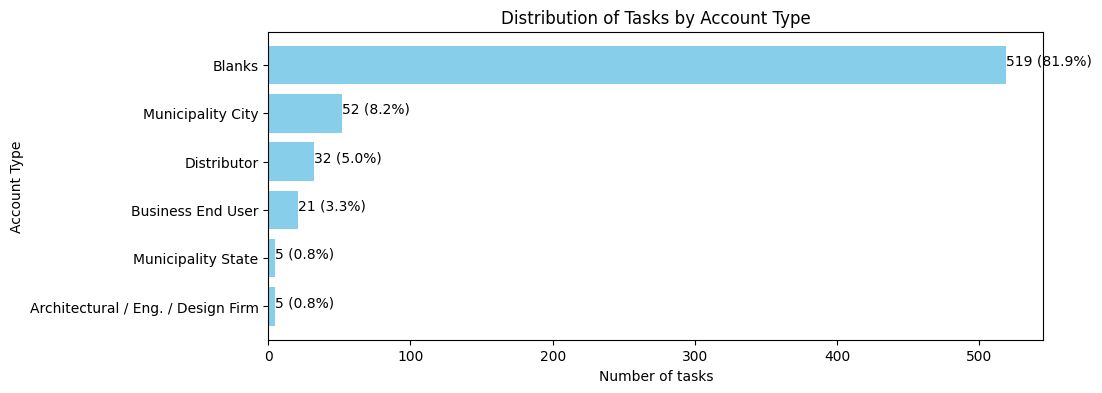

In [108]:
# Looking to column Account Type who has the highest tasks count in the All_US_Open_Tasks_df, include blanks in the values too
# Replace NaNs with a string 'Blanks'
All_US_Open_Tasks_df['Account Type'].fillna('Blanks', inplace=True)

# Looking to column `Account Type` who has the highest tasks count in the All_US_Open_Tasks_df, include `blanks` in the values too
type_task_counts = All_US_Open_Tasks_df['Account Type'].value_counts(dropna=False)

# Sort the counts in descending order
type_task_counts = type_task_counts.sort_values(ascending=False)

# Create labels with counts and percentages
labels_with_counts = [f'{label}: {count} ({count/len(All_US_Open_Tasks_df)*100:.1f}%)' for label, count in zip(type_task_counts.index, type_task_counts)]

# Visualize with horizontal bar chart and add total counts and percentages to the bars
plt.figure(figsize=(10, 4))
plt.barh(type_task_counts.index, type_task_counts, color='skyblue')
for index, value in enumerate(type_task_counts):
    plt.text(value, index, f'{value} ({value/len(All_US_Open_Tasks_df)*100:.1f}%)')
plt.title('Distribution of Tasks by Account Type')
plt.xlabel('Number of tasks')
plt.ylabel('Account Type')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()



Total number of tasks with no Contact and Lead: 146
Total number of tasks with no Contact or Lead: 634


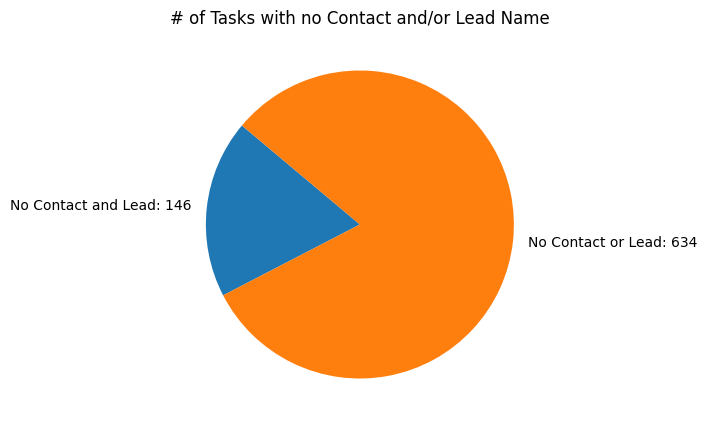

In [109]:
# Count and Visualize total number of tasks which has `blanks` both in columns `Contact` and `Lead`  
# Count the number of rows where both columns are NaN
no_contact_lead = All_US_Open_Tasks_df[(All_US_Open_Tasks_df['Contact'].isna()) & (All_US_Open_Tasks_df['Lead'].isna())].shape[0]

# Count the number of rows where at least one of the columns is NaN
no_contact_or_lead = All_US_Open_Tasks_df[(All_US_Open_Tasks_df['Contact'].isna()) | (All_US_Open_Tasks_df['Lead'].isna())].shape[0]

# Print the results
print(f'Total number of tasks with no Contact and Lead: {no_contact_lead}')
print(f'Total number of tasks with no Contact or Lead: {no_contact_or_lead}')

# Visualize the results with a pie chart
plt.figure(figsize=(5, 5))
plt.pie([no_contact_lead, no_contact_or_lead], labels=[f'No Contact and Lead: {no_contact_lead}', f'No Contact or Lead: {no_contact_or_lead}'], startangle=140)
plt.title('# of Tasks with no Contact and/or Lead Name')
plt.show()

In [ ]:
# Count and visualize the total count number looking to column `Contact/Lead Source` including `blanks` values in the All_US_Open_Tasks_df

# Replace NaNs with a string 'Blanks'
All_US_Open_Tasks_df['Contact/Lead Source'].fillna('Blanks', inplace=True)

# Count the number of tasks for each Lead Source
lead_source_counts = All_US_Open_Tasks_df['Contact/Lead Source'].value_counts(dropna=False)

# Sort the counts in descending order
lead_source_counts = lead_source_counts.sort_values(ascending=False)

# Print the results
print(lead_source_counts)

# Visualize the results with a horizontal bar chart and add total counts and percentages to the bars, also count `blanks` values
plt.figure(figsize=(10, 4))
plt.barh(lead_source_counts.index, lead_source_counts, color='skyblue')
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, f'{value} ({value/lead_source_counts.sum()*100:.1f}%)')
plt.title('# of Tasks by Lead Source')
plt.xlabel('Number of tasks')
plt.ylabel('Lead Source')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()



In [ ]:
# looking to columns `Created By` and `Assigned` visualize the total number of tasks by each person in the All_US_Open_Tasks_df
# Count the number of tasks for each person in the `Created By` column
# Count the number of tasks for each person in the `Assigned` column
# Replace NaNs with a string 'Blanks'
# Rename the index using the mapping dictionary
# Visualize the results with a horizontal bar chart in descending order
# Add counts to the bars
# Add title, x and y labels
# Show the plot
# Count the number of tasks for each person in the `Created By` column
# Count the number of tasks for each person in the `Assigned` column
# Replace NaNs with a string 'Blanks'
All_US_Open_Tasks_df['Created By'].fillna('Blanks', inplace=True)
All_US_Open_Tasks_df['Assigned'].fillna('Blanks', inplace=True)

# Count the number of tasks for each person in the `Created By` column
created_by_counts = All_US_Open_Tasks_df['Created By'].value_counts()

# Count the number of tasks for each person in the `Assigned` column
assigned_counts = All_US_Open_Tasks_df['Assigned'].value_counts()

# Rename the index using the mapping dictionary
created_by_counts.index = created_by_counts.index.map(lambda name: name_to_title.get(name, name))
assigned_counts.index = assigned_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
#add counts to the bars
plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1)
created_by_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(created_by_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('# of Tasks Created by Person')
plt.xlabel('Number of tasks')
plt.ylabel('Created By')

plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 2)
assigned_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(assigned_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('# of Tasks Assigned by Person')
plt.xlabel('Number of tasks')
plt.ylabel('Assigned')
plt.tight_layout()
plt.show()

Account/Lead Rating
Blanks    550
Hot        70
Warm       10
Cold        4
Name: count, dtype: int64


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_7056\3485422734.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  All_US_Open_Tasks_df['Account/Lead Rating'].fillna('Blanks', inplace=True)


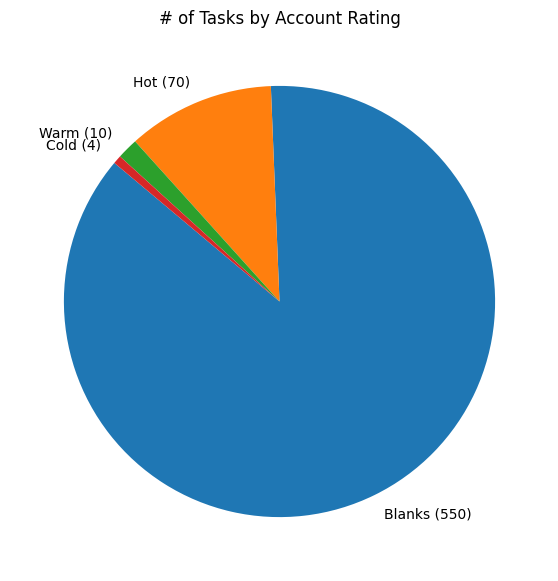

In [112]:
# Visualize with a pie chart looking to `Account/Lead Rating` column in the All_US_Open_Tasks_df including blanks values
# Replace NaNs with a string 'Blanks'
# Count the number of tasks for each Account Rating
# Sort the counts in descending order
# Print the results
# Visualize the results with a pie chart
# Count the number of tasks for each Account Rating
# Sort the counts in descending order
# Print the results
# Visualize the results with a pie chart
# Replace NaNs with a string 'Blanks'
All_US_Open_Tasks_df['Account/Lead Rating'].fillna('Blanks', inplace=True)

# Count the number of tasks for each Account Rating
account_rating_counts = All_US_Open_Tasks_df['Account/Lead Rating'].value_counts(dropna=False)

# Sort the counts in descending order
account_rating_counts = account_rating_counts.sort_values(ascending=False)

# Print the results
print(account_rating_counts)

# Visualize the results with a pie chart
plt.figure(figsize=(7, 7))
plt.pie(account_rating_counts, labels=[f'{label} ({count})' for label, count in zip(account_rating_counts.index, account_rating_counts)], startangle=140)
plt.title('# of Tasks by Account Rating')
plt.show()



### Analysis of Salesforce Report `US Lead Status Grouped by Owner` 

C:\Users\ykilinc\AppData\Local\Temp\ipykernel_7056\110395451.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  US_Lead_Status_by_Owner_df['Converted Lead'].fillna('Blanks', inplace=True)


Converted Lead
Blanks    3776
No         161
Name: count, dtype: int64
Lead Status
New          3613
Working       221
Samples        54
Qualified      31
Nurturing      18
Name: count, dtype: int64


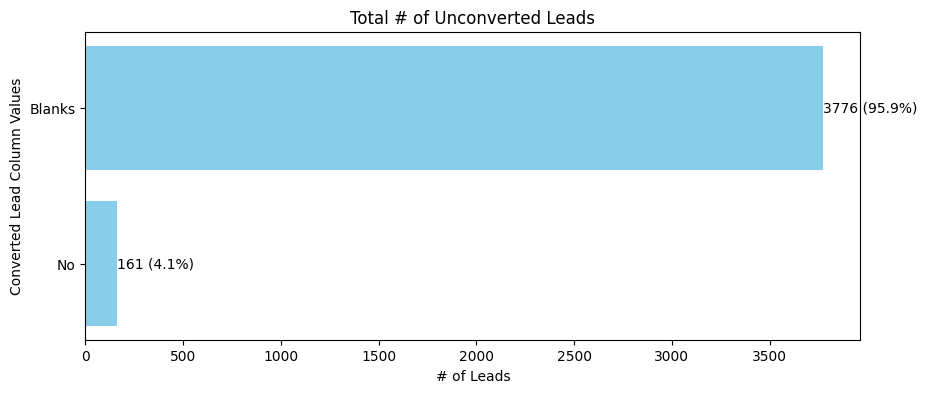

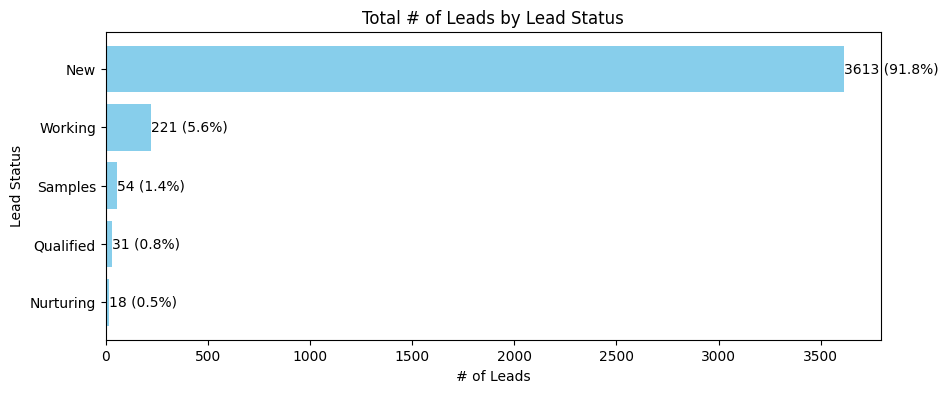

In [113]:
# looking to columns `Converted Lead` and `Lead Staus` print and visualize both columns in the US_Lead_Status_by_Owner_df
# including Blanks values in the `Converted Lead` column

# Replace NaNs with a string 'Blanks'
US_Lead_Status_by_Owner_df['Converted Lead'].fillna('Blanks', inplace=True)

# Count the number of tasks for each Converted Lead status
converted_lead_counts = US_Lead_Status_by_Owner_df['Converted Lead'].value_counts(dropna=False)

# Count the number of tasks for each Lead Status
lead_status_counts = US_Lead_Status_by_Owner_df['Lead Status'].value_counts()

# Print the results
print(converted_lead_counts)
print(lead_status_counts)

# Visualize the results with a horizontal bar chart and add total counts and percentages to the bars
plt.figure(figsize=(10, 4))
plt.barh(converted_lead_counts.index, converted_lead_counts, color='skyblue')
for index, value in enumerate(converted_lead_counts):
    plt.text(value, index, f'{value} ({value/converted_lead_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Unconverted Leads')
plt.xlabel('# of Leads')
plt.ylabel('Converted Lead Column Values')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

plt.figure(figsize=(10, 4))
plt.barh(lead_status_counts.index, lead_status_counts, color='skyblue')
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, f'{value} ({value/lead_status_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Leads by Lead Status')
plt.xlabel('# of Leads')
plt.ylabel('Lead Status')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

In [ ]:
# visualize total number of leads looking into `Created By:Full Name` column in the US_Lead_Status_by_Owner_df

# Count the number of leads for each person in the `Created By:Full Name` column
created_by_counts = US_Lead_Status_by_Owner_df['Created By: Full Name'].value_counts()

# Rename the index using the mapping dictionary
created_by_counts.index = created_by_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 4))
created_by_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(created_by_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total # of Leads Created by Person')
plt.xlabel('# of Leads')
plt.ylabel('Created By')
plt.show()

In [ ]:
# visualize total number of leads looking into `Lead Owner: Full Name` column in the US_Lead_Status_by_Owner_df

# Count the number of leads for each person in the `Lead Owner: Full Name` column
assigned_counts = US_Lead_Status_by_Owner_df['Lead Owner: Full Name'].value_counts()

# Rename the index using the mapping dictionary
assigned_counts.index = assigned_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 10))
assigned_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(assigned_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total Number of Leads by Owner')
plt.xlabel('Number of leads')
plt.ylabel('Assigned')
plt.show()

In [ ]:
# visualize column `Lead Source` in the US_LeadStatus_by_LeadSource_df, including blanks values and by counting the number of leads

# Replace NaNs with a string 'Blanks'
US_LeadStatus_by_LeadSource_df['Lead Source'].fillna('Blanks', inplace=True)

# Count the number of leads for each Lead Source
lead_source_counts = US_LeadStatus_by_LeadSource_df['Lead Source'].value_counts(dropna=False)

# Sort the counts in descending order
lead_source_counts = lead_source_counts.sort_values(ascending=False)

# Print the results
print(lead_source_counts)

# Visualize the results with a horizontal bar chart and add total counts and percentages to the bars
plt.figure(figsize=(10, 4))
plt.barh(lead_source_counts.index, lead_source_counts, color='skyblue')
for index, value in enumerate(lead_source_counts):
    plt.text(value, index, f'{value} ({value/lead_source_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Leads by Lead Source')
plt.xlabel('# of leads')
plt.ylabel('Lead Source')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

### Analysis of Salesforce Report `US Lead Status Grouped by Lead Source`

In [ ]:
# count and visualize total number of `Lead Status` in the US_LeadStatus_by_LeadSource_df

# Count the number of leads for each Lead Status
lead_status_counts = US_LeadStatus_by_LeadSource_df['Lead Status'].value_counts()

# Print the results
print(lead_status_counts)

# Visualize the results with a horizontal bar chart and add total counts and percentages to the bars
plt.figure(figsize=(10, 4))
plt.barh(lead_status_counts.index, lead_status_counts, color='skyblue')
for index, value in enumerate(lead_status_counts):
    plt.text(value, index, f'{value} ({value/lead_status_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Leads by Lead Status')
plt.xlabel('# of leads')
plt.ylabel('Lead Status')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

In [ ]:
# Prepare the data
pivot_table = US_LeadStatus_by_LeadSource_df.pivot_table(index='Lead Source', columns='Lead Status', aggfunc='size', fill_value=0)

# Plot a heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='viridis')
plt.title('Heatmap of Leads by Lead Source and Lead Status')
plt.xlabel('Lead Status')
plt.ylabel('Lead Source')
plt.show()

In [ ]:
# visualize qualified and unqualified leads by lead source in the US_LeadStatus_by_LeadSource_df

# Count the number of qualified and unqualified leads for each Lead Source
qualified_counts = US_LeadStatus_by_LeadSource_df[US_LeadStatus_by_LeadSource_df['Lead Status'] == 'Qualified']['Lead Source'].value_counts()
unqualified_counts = US_LeadStatus_by_LeadSource_df[US_LeadStatus_by_LeadSource_df['Lead Status'] == 'Unqualified']['Lead Source'].value_counts()

# Sort the counts in descending order
qualified_counts = qualified_counts.sort_values(ascending=False)
unqualified_counts = unqualified_counts.sort_values(ascending=False)

# Print the results
print(qualified_counts)
print(unqualified_counts)

# Visualize the results with a horizontal bar chart and add total counts and percentages to the bars
plt.figure(figsize=(10, 4))
plt.barh(qualified_counts.index, qualified_counts, color='skyblue')
for index, value in enumerate(qualified_counts):
    plt.text(value, index, f'{value} ({value/qualified_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Qualified Leads by Lead Source')
plt.xlabel('# of leads')
plt.ylabel('Lead Source')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

plt.figure(figsize=(10, 4))
plt.barh(unqualified_counts.index, unqualified_counts, color='skyblue')
for index, value in enumerate(unqualified_counts):
    plt.text(value, index, f'{value} ({value/unqualified_counts.sum()*100:.1f}%)', va='center')
plt.title('Total # of Unqualified Leads by Lead Source')
plt.xlabel('# of leads')
plt.ylabel('Lead Source')
plt.gca().invert_yaxis()  # To display the highest values at the top
plt.show()

In [ ]:
# visualize total number of leads by Created By: Full Name in the US_LeadStatus_by_LeadSource_df including blanks values

# Count the number of leads for each person in the `Created By: Full Name` column
created_by_counts = US_LeadStatus_by_LeadSource_df['Created By: Full Name'].value_counts()

# Rename the index using the mapping dictionary
created_by_counts.index = created_by_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 4))
created_by_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(created_by_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total # of Leads Created by Person')
plt.xlabel('# of leads')
plt.ylabel('Created By')
plt.show()

In [ ]:
# Visualize total number of Unqulaified Leads by Lead Owner including blanks values in the US_LeadStatus_by_LeadSource_df

# Count the number of unqualified leads for each person in the `Lead Owner: Full Name` column
unqualified_counts = US_LeadStatus_by_LeadSource_df[US_LeadStatus_by_LeadSource_df['Lead Status'] == 'Unqualified']['Lead Owner: Full Name'].value_counts()

# Rename the index using the mapping dictionary
unqualified_counts.index = unqualified_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 4))
unqualified_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(unqualified_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total # of Unqualified Leads by Owner')
plt.xlabel('# of leads')
plt.ylabel('Assigned')
plt.show()

In [ ]:
# visualize total number of qualified leads by lead owner in the US_LeadStatus_by_LeadSource_df including blanks values

# Count the number of qualified leads for each person in the `Lead Owner: Full Name` column
qualified_counts = US_LeadStatus_by_LeadSource_df[US_LeadStatus_by_LeadSource_df['Lead Status'] == 'Qualified']['Lead Owner: Full Name'].value_counts()

# Rename the index using the mapping dictionary
qualified_counts.index = qualified_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 4))
qualified_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(qualified_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total # of Qualified Leads by Owner')
plt.xlabel('# of leads')
plt.ylabel('Assigned')
plt.show()



In [ ]:
# visualize total number of New leads by Lead Owner including blanks values in the US_LeadStatus_by_LeadSource_df

# Count the number of new leads for each person in the `Lead Owner: Full Name` column
new_counts = US_LeadStatus_by_LeadSource_df[US_LeadStatus_by_LeadSource_df['Lead Status'] == 'New']['Lead Owner: Full Name'].value_counts()

# Rename the index using the mapping dictionary
new_counts.index = new_counts.index.map(lambda name: name_to_title.get(name, name))

# Visualize the results with a horizontal bar chart in descending order
plt.figure(figsize=(20, 8))
new_counts.sort_values().plot(kind='barh', color='skyblue')
for index, value in enumerate(new_counts.sort_values()):
    plt.text(value, index, str(value))
plt.title('Total # of New Leads by Owner')
plt.xlabel('# of leads')
plt.ylabel('Assigned')
plt.show()

Lead Currency
CAD    5007
USD      23
Name: count, dtype: int64


C:\Users\ykilinc\AppData\Local\Temp\ipykernel_7056\3520176237.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  US_LeadStatus_by_LeadSource_df['Lead Currency'].fillna('Blanks', inplace=True)


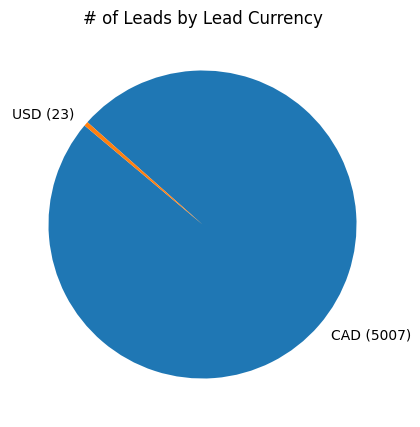

In [124]:
# visualize Lead Currency with a pie chart in the US_LeadStatus_by_LeadSource_df including blanks values

# Replace NaNs with a string 'Blanks'
US_LeadStatus_by_LeadSource_df['Lead Currency'].fillna('Blanks', inplace=True)

# Count the number of leads for each Lead Currency
lead_currency_counts = US_LeadStatus_by_LeadSource_df['Lead Currency'].value_counts(dropna=False)

# Sort the counts in descending order
lead_currency_counts = lead_currency_counts.sort_values(ascending=False)

# Print the results
print(lead_currency_counts)

# Visualize the results with a pie chart
plt.figure(figsize=(5, 5))
plt.pie(lead_currency_counts, labels=[f'{label} ({count})' for label, count in zip(lead_currency_counts.index, lead_currency_counts)], startangle=140)
plt.title('# of Leads by Lead Currency')
plt.show()
